In [1]:
import phoenix as px
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

# 1. Запускаем сам сервер Phoenix
session = px.launch_app()

# 2. Регистрируем провайдер трассировки (OpenTelemetry)
# Он будет перехватывать данные и отправлять их в локальный Phoenix
tracer_provider = register()

# 3. Включаем "прослушку" именно для LangChain
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

print(f"Phoenix готов! Дашборд тут: {session.url}")

/Users/artemzmailov/Desktop/kitoboy-PII/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/artemzmailov/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
/Users/artemzmailov/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Phoenix готов! Дашборд тут: http://localhost:6006/


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# Теперь к ним можно обращаться через стандартный модуль os
api_key = os.getenv("MISTRAL_API_KEY")
print(api_key)

Lld8KeTo2clg7lurqzk9G0XZlCuGBdhx


In [3]:
import yaml
import re
from typing import List, Set, TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END

# Модель для structured_output (как ты и писал)
class Entities(BaseModel):
    items: List[str] = Field(description="Список сгенерированных сущностей")

# Состояние нашего подграфа
class SubAgentState(TypedDict):
    entity_key: str          # Ключ из YAML (например, 'PASSPORT_RF')
    target_count: int        # Сколько всего нужно уникальных штук
    unique_samples: Set[str] # Наше множество (авто-дедупликация)
    last_batch: List[str]    # Последний выхлоп модели (для логов/проверки)
    retries: int             # Счетчик итераций

In [4]:
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_mistralai import ChatMistralAI

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.3,   
    check_every_n_seconds=0.1,
    max_bucket_size=1,
)

In [5]:
from langchain_mistralai import ChatMistralAI

# Инициализация модели
llm = ChatMistralAI(model="mistral-small-2506", #mistral-small-2506
                    temperature=0.7,
                    timeout = 60,
                    rate_limiter=rate_limiter,
                    max_concurrent_requests=1,
                    max_retries=3)
structured_llm = llm.with_structured_output(Entities)

#llm = ChatOllama(model="qwen3.5:9b", reasoning = False, format="json", temperature=0.7)
# structured_llm = llm.with_structured_output(Entities)

# Загрузка промптов (предположим, файл лежит рядом)
with open('../../configs/prompts.yaml', 'r', encoding='utf-8') as f:
    PROMPTS_CONFIG = yaml.safe_load(f)

def generate_batch_node(state: SubAgentState):
    entity_key = state['entity_key']
    config = PROMPTS_CONFIG.get('ENTITIES', {}).get(entity_key)
    
    if config is None:
        raise ValueError(f"Сущность {entity_key} не найдена в секции ENTITIES в prompts.yaml")
    
    # Считаем, сколько еще не хватает до цели
    needed = state['target_count'] - len(state['unique_samples'])
    batch_size = min(needed, 10) # Генерим не больше 10 за раз для качества
    
    # Берем системный промпт и подставляем N
    sys_prompt = config['system_prompt'].format(N=batch_size)
    
    # Формируем подсказку, чтобы не повторяться (берем последние 5 примеров)
    history = list(state['unique_samples'])[-5:]
    user_content = f"Сгенерируй {batch_size} новых примеров."
    if history:
        user_content += f" Не повторяй эти форматы: {history}. Попробуй другие форматы записи, разделители или цифры."
    
    messages = [
        SystemMessage(content=sys_prompt),
        HumanMessage(content=user_content)
    ]
    
    # Вызов модели
    response = structured_llm.invoke(messages)
    
    return {
        "last_batch": response.items,
        "retries": state['retries'] + 1
    }

def validate_and_add_node(state: SubAgentState):
    # Просто добавляем всё, что выдала модель, в set()
    # Так как мы отказались от регулярок, тут только дедупликация
    new_items = state['last_batch']
    updated_samples = state['unique_samples'].copy()
    
    for item in new_items:
        if item and len(item) > 5: # Базовый фильтр от пустых строк
            updated_samples.add(item)
            
    return {"unique_samples": updated_samples}

In [6]:
def should_continue(state: SubAgentState):
    # Если набрали нужное количество или превысили лимит попыток (напр. 20)
    if len(state['unique_samples']) >= state['target_count'] or state['retries'] > 20:
        return "end"
    return "continue"

# Собираем граф
workflow = StateGraph(SubAgentState)

# Добавляем узлы
workflow.add_node("generator", generate_batch_node)
workflow.add_node("validator", validate_and_add_node)

# Устанавливаем точку входа
workflow.set_entry_point("generator")

# Связываем узлы
workflow.add_edge("generator", "validator")

# Добавляем условный переход из валидатора
workflow.add_conditional_edges(
    "validator",
    should_continue,
    {
        "continue": "generator",
        "end": END
    }
)

# Компилируем
sub_agent_app = workflow.compile()

In [7]:
import random
from typing import List, Dict, TypedDict, Annotated, Optional
import operator

class FinalResult(TypedDict):
    text: str
    used_entities: List[Dict[str, str]]
    source_fragment: str
# State с поддержкой словаря конфигураций
class OrchestratorState(TypedDict):
    random_seed: int
    total_n: Optional[int]                 # Желаемое общее кол-во типов сущностей
    entity_config: Dict[str, int]          # Словарь {"название": количество}
    default_m: int                         # Сколько генерить, если в словаре нет ключа
    
    # Внутренние поля
    tasks: Dict[str, int]                  # Итоговый план работ: {"ENTITY": M}
    collected_data: Annotated[Dict[str, Set[str]], operator.ior]
    inventory: Dict[str, Set[str]]
    # Сюда синтезатор кладет результат одной итерации для проверки
    current_task_result: Optional[FinalResult]
    
    # Сюда попадают только ПРОВЕРЕННЫЕ пары {text, entities}
    final_results: Annotated[List[FinalResult], operator.add]
    
    consecutive_errors: int

TEXT_FRAGMENTS_POOL: list[str] = []


# --- УЗЛЫ ---



def setup_tasks_node(state: OrchestratorState):
    """Формирует финальный план: какая сущность -> сколько штук"""
    # Список всех доступных сущностей (кроме служебных полей типа ORCHESTRATOR)

    seed = state.get("random_seed")
    if seed is not None:
        random.seed(seed)
    available_entities = list(PROMPTS_CONFIG['ENTITIES'].keys())
    
    print(f"📊 Доступно типов для генерации: {available_entities}")
    max_entities = len(available_entities)
    
    tasks = state['entity_config'].copy()

    excluded = {k for k, v in tasks.items() if v <= 0}
    tasks = {k: v for k, v in tasks.items() if v > 0}

    # Определяем, сколько всего типов сущностей нам нужно
    # Если total_n не задан, берем длину словаря. Если задан - проверяем лимиты.
    target_n = state.get('total_n') or len(tasks)
    
    # ЗАЩИТА: Нельзя выбрать больше, чем у нас есть в конфиге
    if target_n > max_entities:
        print(f"Внимание: Запрошено {target_n} типов, но в YAML всего {max_entities}. Снижаем до лимита.")
        target_n = max_entities

    # Добираем рандомом, если в словаре меньше сущностей, чем target_n
    if len(tasks) < target_n:
        # Выбираем только из тех, которых еще нет в tasks
        remaining = [e for e in available_entities if e not in tasks and e not in excluded]

        needed = min(target_n - len(tasks), len(remaining))
        
        # Выбираем ровно столько, сколько не хватает до лимита
        for ent in random.sample(remaining, needed):
            tasks[ent] = state['default_m']

    # Проверка на нулевые значения
    tasks = {k: v for k, v in tasks.items() if v > 0}
    
    print(f"📋 Итоговый план генерации: {tasks}")
    return {"tasks": tasks, "collected_data": {}}

def call_subagents_node(state: OrchestratorState):
    """Итерируемся по задачам и дергаем наш sub_agent_app"""
    results = {}
    
    for entity, m_count in state['tasks'].items():
        print(f"📡 Запрос к субагенту [{entity}] на {m_count} штук...")
        
        sub_input = {
            "entity_key": entity,
            "target_count": m_count,
            "unique_samples": set(),
            "retries": 0
        }
        
        # Вызов твоего скомпилированного графа
        sub_result = sub_agent_app.invoke(sub_input)
        results[entity] = sub_result['unique_samples']
        
    return {"collected_data": results}
def prepare_inventory_node(state: OrchestratorState):
    source = state.get("collected_data", {})
    # Создаем новые сеты, чтобы inventory был независимым
    clean_copy = {k: set(v) for k, v in source.items()}
    print(f"📦 Инвентарь подготовлен: {len(clean_copy)} категорий скопировано.")
    return {"inventory": clean_copy}

In [8]:
from pydantic import BaseModel, Field
from typing import List

class EntityItem(BaseModel):
    key: str = Field(description="Название категории (например, PASSPORT_RF)")
    value: str = Field(description="Само значение данных, вставленное в текст")

# 2. Используем её в основной модели
class SynthesisResponse(BaseModel):
    text: str = Field(description="Текст поста", default='')
    # Теперь тут не просто Dict, а список объектов EntityItem
    entities: List[EntityItem] = Field(
        description="Список вставленных сущностей и их значений в текст",
        default_factory=list
    )

In [9]:
from langchain_core.tools import tool
from langchain_core.runnables.config import RunnableConfig
from typing import List, Dict

@tool
def plan_insertion(logic_of_entry: str, chosen_data: List[EntityItem], config: RunnableConfig):
    """
    ПЕРВЫЙ ШАГ: Пойми, зачем человеку в этом тексте вообще называть свои данные. 
    logic_of_entry: Объясни, какой житейский повод заставил автора упомянуть эти данные.
    chosen_data: Список объектов EntityItem(key="КАТЕГОРИЯ", value="ЗНАЧЕНИЕ")
                 КАТЕГОРИЯ — это строго название категории данных из ДОСТУПНОГО ПУЛА.
                 ЗНАЧЕНИЕ — это конкретный пример данных соответствующей категории.
    Ты должен добавить в chosen_data только те ЗНАЧЕНИЯ и их КАТЕГОРИИ, которые впишутся в этот 'повод' без фальши и будут вставлены в текст.
    ВАЖНО: 
    1. Ты получаешь на вход словарь 'inventory', где КЛЮЧ — это категория данных, а ЗНАЧЕНИЕ — список доступных строк (конкретных примеров этой категории).
    2. Выбирай только те значения, которые реально присутствуют в предоставленном inventory.
    3. В поле 'value' передавай строку из списка целиком, без изменений, она является цельным примером.
    Пример: если в inventory есть {"PASSPORT_RF": ["4511 123456"]}, твой chosen_data должен быть:
    [{"key": "PASSPORT_RF", "value": "4511 123456"}]
    """
    local_storage = config["configurable"].get("synthesis_storage")
    
    if local_storage:
        local_storage.entities = chosen_data
    
    print(f"\n[PLAN] 💭 Логика: {logic_of_entry}")
    print(f"[PLAN] ✅ В память занесено (значения): {chosen_data}")
    return f"Понял, вписываем через: {logic_of_entry}. Берем категории и значения: {chosen_data}"

@tool
def write_draft(text: str, config: RunnableConfig):
    """
    ВТОРОЙ ШАГ: Напиши само сообщение. 
    Текст должен остаться живым: сбивчивым, эмоциональным или деловым — смотря какой оригинал. 
    
    КРИТИЧЕСКИ ВАЖНО: 
    1. Используй ТОЛЬКО те конкретные значения данных, которые ты указал в "value" в plan_insertion (chosen_data). 
    2. Не вставляй лишние данные из пула, если их не было в плане.
    3. Данные ОБЯЗАТЕЛЬНО оборачивай в ПАРНЫЕ теги: <ENTITY_KEY>данные</ENTITY_KEY>, где ENTITY_KEY - это название Категории в plan_insertion (chosen_data).
    4. Переход к данным должен быть семантически связан с соседними предложениями и не должен выглядеть как универсальная вставка-шаблон или звучать искусственно.

    
    Пример: Мой паспорт <PASSPORT_RF>45 12 123456</PASSPORT_RF>.
    """
    local_storage = config["configurable"].get("synthesis_storage")
    
    if local_storage:
        local_storage.text = text
    print(f"\n[DRAFT] ✍️ Текст генерируется на основе выбранных данных...")
    return "Черновик готов. Иду проверять на соответствие плану и фальшь."

@tool
def verify_integrity(critique: str, feels_real: bool, matches_plan: bool, config: RunnableConfig):
    """
    ТРЕТИЙ ШАГ: Честный самоаудит. 
    
    matches_plan: СТРОГО проверь, что все значения из plan_insertion (chosen_data) 
                  вставлены в текст и ОБЯЗАТЕЛЬНО обернуты в парные теги <ENTITY_KEY>...</ENTITY_KEY>.
                  ВАЖНО:
                  Если хоть одно значение осталось не обернуто тегами <ENTITY_KEY>...</ENTITY_KEY> или данные не совпадают — ставь False!
    feels_real: ПРОВЕРКА НА ЧЕЛОВЕЧНОСТЬ. 
                  Ставь True, если текст написан живым языком. 
                  ВНИМАНИЕ: Оценивай естественность перехода по локальному контексту. 
                  Если вставка выглядит как универсальный шаблонный переход и не опирается на соседние фразы или текст стал бессвязным набором слов, ставь False.
    critique: Что именно режет глаз? (Слишком сухо, данные висят в воздухе, нарушена логика речи, нет обрамления значения тегами или, например, в плане 2 значения, а в тексте одно).
    """
    storage: SynthesisResponse = config.get("configurable", {}).get("synthesis_storage")
    
    if not storage or not storage.text:
        return "ОШИБКА: Текст сообщения не найден. Сначала необходимо сформировать черновик."

    draft_text = storage.text
    planned_keys = [item.key for item in storage.entities] if storage.entities else []
    
    # 1. Техническая проверка тегов (то, что не умеет LLM, но умеет Python)
    missing_tags = []
    for key in planned_keys:
        if f"<{key}>" not in draft_text or f"</{key}>" not in draft_text:
            missing_tags.append(key)

    # 2. Итоговый статус успеха
    actual_success = feels_real and matches_plan and not missing_tags

    if actual_success:
        print(f"\n[VERIFY] Пройдено: {critique}")
        return "Текст идеален, разметка на месте. Завершай работу."
    else:
        # Формируем подсказку, почему именно не прошли
        reasons = []
        if missing_tags:
            reasons.append(f"Отсутствуют или не закрыты теги для категорий: {', '.join(missing_tags)}")
        if not matches_plan:
            reasons.append("Несоответствие данных выбранному плану")
        if not feels_real:
            reasons.append("Текст звучит неестественно (фальшь)")
            
        feedback = " | ".join(reasons)
        print(f"\n[VERIFY] Ошибка: {feedback} (Критика: {critique})")
        
        return (f"Исправь ошибки ({feedback}). Критика: {critique}. "
                f"Перепиши черновик, убедившись, что ВСЕ данные из плана "
                f"корректно вставлены и обернуты в теги.")
tools = [plan_insertion, write_draft, verify_integrity]

In [10]:
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage, HumanMessage

# Собираем production-ready агента. 
# В v1.0+ он автоматически работает как граф без AgentExecutor.
synthesizer_agent = create_agent(
    model=llm, 
    tools=tools,
    
)

In [11]:
def synthesis_node(state: Dict):
    
    inventory = state.get('inventory', {})
    if not inventory:
        print("⚠️ Синтезатор вызван, но inventory пуст!")
        return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}

    success = False
    attempts = 0
    while not success and attempts < 3:
        attempts += 1
        local_synthesis = SynthesisResponse()
        base_text = random.choice(TEXT_FRAGMENTS_POOL)
   
        # Сбор данных из стейта для промпта
        #available_data = {k: list(v) for k, v in inventory.items()}
        active_categories = [k for k, v in inventory.items() if v]
        
        # 2. Решаем, сколько категорий выставить на витрину (от 2 до 4)
        n_categories = min(len(active_categories), random.randint(2, 4))
        sampled_categories = random.sample(active_categories, n_categories)
        
        # 3. Решаем, сколько примеров брать из каждой категории
        # Если категорий мало (1 или 2), берем по 2 примера для выбора
        items_per_category = 2 if n_categories <= 2 else 1
        
        available_data = {}
        for cat in sampled_categories:
            source_values = list(inventory[cat])
            
            # Берем столько, сколько решили, но не больше, чем есть по факту
            n_examples = min(len(source_values), items_per_category)
            
            # random.sample сразу гарантирует, что примеры будут разные
            available_data[cat] = random.sample(source_values, n_examples)
        system_msg = SystemMessage(content=PROMPTS_CONFIG['NODES']['SYNTHESIZER_AGENT']['system_prompt'])

        position_hints = [
            "Постарайся органично вставить данные в начале текста (в первых 1-2 предложениях).",
            "Постарайся органично вставить данные в середине текста (внутри основной мысли).",
            "Постарайся органично вставить данные в конце текста (как естественное завершение мысли).",
        ]
        position_hint = random.choice(position_hints)

        
        human_msg = HumanMessage(content=(
            f" ВХОДНЫЕ ДАННЫЕ ДЛЯ РАБОТЫ:\n"
            f"1. ИСХОДНЫЙ ТЕКСТ-ОСНОВА:\n\"{base_text}\"\n\n"
            f"2. ДОСТУПНЫЙ ПУЛ ДАННЫХ ДЛЯ ВСТАВКИ:\n{available_data}\n\n"
            f"3. ДОП. РЕЖИМ ВСТАВКИ:\n{position_hint}\n\n"
            f"ТВОЁ ЗАДАНИЕ:\n"
            f"Сначала спланируй, какие данные ты будешь вставлять в текст (Plan), если план не содержит данные, а только их категории или какой-то мусор, то спланируй снова."
            f"Когда план будет готов, начинай писать текст (Draft) и затем проверяй его (Verify), если результат проверки неудовлетворительный, начинай писать текст сначала.\n\n"
            f"КРИТИЧЕСКИЕ НАПОМИНАНИЯ:\n"
            f"- В tool 'plan_insertion' передавай словарь НАЗВАНИЕ КАТЕГОРИИ: КОНКРЕТНЫЕ СТРОКИ (значения) из этой категории.\n"
            f"- Используй СТРОГО те значения, которые ты выберешь и зафиксируешь на этапе планирования.\n"
            f"- Не забудь про парные теги <ENTITY_KEY>...</ENTITY_KEY> для разметки данных в тексте.\n\n"
        ))
        response = synthesizer_agent.invoke( 
            {"messages": [system_msg, human_msg]},
            config = {"configurable": {"synthesis_storage": local_synthesis}}
        )
        if local_synthesis.text and local_synthesis.entities:
            success = True
            used_entities = [{"key": e.key, "value": e.value} for e in local_synthesis.entities]
            print(f"\n✅ Синтез завершен. Из памяти SynthesisResponse извлечено: {len(local_synthesis.entities)}")
                
            # ВОЗВРАЩАЕМ В БУФЕР (current_task_result), а не сразу в финал
            return {
                "current_task_result": { 
                    "text": local_synthesis.text,
                    "used_entities": used_entities,
                    "source_fragment": base_text,
                    "position_hint": position_hint,  # опционально
                }
            }
        print(f"⚠️ Попытка {attempts} не удалась, текст '{base_text[:30]}...' был неудобным. Выбираем новый текст.")

    return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}

In [12]:
def inventory_cleanup_node(state: OrchestratorState):
    # Снова делаем копию, чтобы не мутировать state напрямую (хороший тон в LangGraph)
    new_inv = {k: set(v) for k, v in state.get('inventory', {}).items()}
    res = state.get('current_task_result')
    
    if not res or not res.get('used_entities'):
        return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}


    # Валидация
    for ent in res['used_entities']:
        cat, val = ent['key'], ent['value']
        if cat in new_inv and val in new_inv[cat]:
            new_inv[cat].remove(val) # Удаляем из сета
            if not new_inv[cat]:
                del new_inv[cat]
        else:
            print(f"⚠️ Галлюцинация или дубль: {cat} -> {val}")
            return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}
        if f"<{cat}>" not in res['text'] or f"</{cat}>" not in res['text']:
            print(f"❌ Ошибка разметки в {cat}")
            return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}


    return {
        "inventory": new_inv, # Заменяет старый inventory целиком
        "final_results": [res],
        "current_task_result": None,
        "consecutive_errors": 0
    }
def should_continue(state: OrchestratorState):
    inv = state.get('inventory', {})
    if not inv:
        print("🏁 Склад пуст, все сущности внедрены.")
        return END
    
    if state.get('consecutive_errors', 0) >= 5:
        print("🛑 Слишком много ошибок подряд.")
        return END
        
    return "synthesizer"

In [13]:
from langgraph.graph import StateGraph, END

# Инициализируем граф на твоем OrchestratorState
orch_workflow = StateGraph(OrchestratorState)

orch_workflow.add_node("planner", setup_tasks_node)
orch_workflow.add_node("executor", call_subagents_node)
orch_workflow.add_node("prepare_inventory", prepare_inventory_node)

orch_workflow.add_node("synthesizer", synthesis_node)
orch_workflow.add_node("cleaner", inventory_cleanup_node) 

# 3. Строим связи (теперь до самого конца)
orch_workflow.set_entry_point("planner")
orch_workflow.add_edge("planner", "executor")
orch_workflow.add_edge("executor", "prepare_inventory")
orch_workflow.add_edge("prepare_inventory", "synthesizer")

orch_workflow.add_edge("synthesizer", "cleaner")
orch_workflow.add_conditional_edges(
    "cleaner",
    should_continue
)
orchestrator_app = orch_workflow.compile()



In [14]:
# image_data = orchestrator_app.get_graph(xray=True).draw_mermaid_png()

# # Записываем их в файл
# with open("graph.png", "wb") as f:
#     f.write(image_data)

# print("Файл graph.png успешно сохранен!")

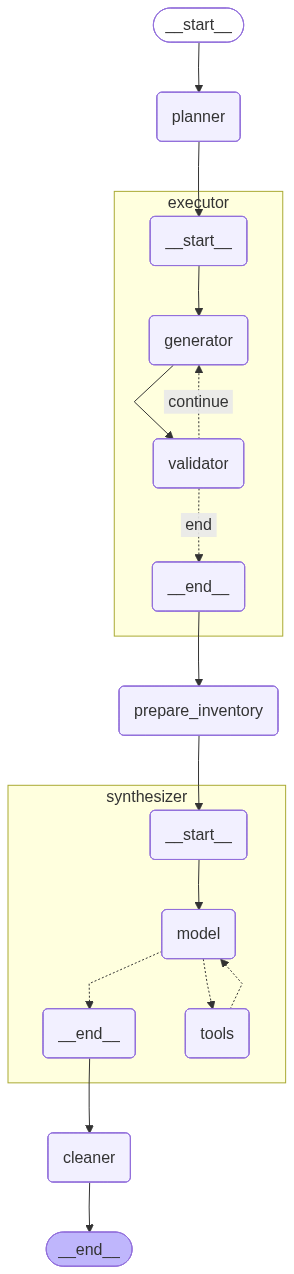

In [15]:
from IPython.display import Image, display
display(Image(orchestrator_app.get_graph(xray=True).draw_mermaid_png()))

In [16]:
import pandas as pd

texts = pd.read_csv('../../data/texts_200_500_symbols.csv', index_col = 0).squeeze()
texts = texts.reset_index(drop = True)
print(texts)
print(texts.info())

text_lst = texts.to_list()


0        Вот как и многие тут мечусь между жизнью и сме...
1        Я устала от жестокости мира, от глупости и жад...
2        Здравствуйте, эта тема и это сообщения ничто. ...
3        мне планируют платить пенсию 130 евро в месяц....
4        У меня букет психических расстройств, всю свою...
                               ...                        
19455    Изменила мужу. Не смогла ему признаться, но и ...
19456    не знаю стоит ли писать. в общем четыре месяца...
19457    Много чего есть рассказать. Коротко. Очень сло...
19458    я просто схожу с ума.в такие моменты хочется и...
19459    Добрый вечер. я думаю о самоубийстве, последне...
Name: text, Length: 19460, dtype: str
<class 'pandas.Series'>
RangeIndex: 19460 entries, 0 to 19459
Series name: text
Non-Null Count  Dtype
--------------  -----
19460 non-null  str  
dtypes: str(1)
memory usage: 10.3 MB
None


In [18]:
TEXT_FRAGMENTS_POOL = text_lst

test_input = {
    "random_seed": None,
    "entity_config": {
        "PASSPORT_RF": 0,
    },
    "total_n": 6,
    "default_m": 2,
    "consecutive_errors": 0, # Инициализируем счетчик
    "iterations": 0,         # Если используешь старое название
    "final_results": []      # Начинаем с пустого списка
}

print("🚀 Запуск Оркестратора: Начинаем цикл генерации датасета...")
print("-" * 60)

import json

# 2. Выполняем прогон графа
# Благодаря циклам внутри, invoke вернет стейт ПОСЛЕ того, как склад опустеет или сработает стоп-кран
final_state = orchestrator_app.invoke(test_input)

print("-" * 60)
print("📦 ФИНАЛЬНЫЙ ОТЧЕТ СИСТЕМЫ:")

results = final_state.get('final_results', [])

if results:
    print(f"\n✅ Успешно синтезировано пар (текст + данные): {len(results)}")
    
    for idx, item in enumerate(results, 1):
        print(f"\n--- ОБЪЕКТ №{idx} ---")
        print(f"📝 ТЕКСТ:\n{item['text']}")
        print(f"\n📊 ИСПОЛЬЗОВАННЫЕ СУЩНОСТИ:")
        for ent in item['used_entities']:
            print(f"  • [{ent['key']}]: {ent['value']}")
        print(f"🔗 ОСНОВА: {item['source_fragment'][:50]}...") 
else:
    print("❌ Система не смогла создать ни одного валидного поста.")

# 4. Проверка остатков на рабочем складе (теперь смотрим в inventory!)
remaining_data = final_state.get('inventory', {}) # <--- Ключевое изменение
errors = final_state.get('consecutive_errors', 0)
# Если счетчик ушел в минус при сбросе, показываем 0
display_errors = max(0, errors) 

print("\n" + "="*60)
print(f"💡 ИТОГОВАЯ СТАТИСТИКА:")
print(f"🗑 Осталось неиспользованных данных: {len(remaining_data)} категорий")
print(f"⚠️ Ошибок подряд на момент завершения: {display_errors}")

if not remaining_data:
    print("🏆 ПОЛНЫЙ УСПЕХ: Все данные из инвентаря внедрены в тексты!")
else:
    # Теперь этот блок сработает только если реально что-то забыли
    for cat, values in remaining_data.items():
        print(f"  - {cat}: {len(values)} шт. осталось")

🚀 Запуск Оркестратора: Начинаем цикл генерации датасета...
------------------------------------------------------------
📊 Доступно типов для генерации: ['PASSPORT_RF', 'BANK_CARD', 'PHONE_NUMBER', 'EMAIL', 'TELEGRAM', 'VK']
📋 Итоговый план генерации: {'EMAIL': 2, 'BANK_CARD': 2, 'VK': 2, 'PHONE_NUMBER': 2, 'TELEGRAM': 2}
📡 Запрос к субагенту [EMAIL] на 2 штук...
📡 Запрос к субагенту [BANK_CARD] на 2 штук...
📡 Запрос к субагенту [VK] на 2 штук...
📡 Запрос к субагенту [PHONE_NUMBER] на 2 штук...
📡 Запрос к субагенту [TELEGRAM] на 2 штук...
📦 Инвентарь подготовлен: 5 категорий скопировано.

[PLAN] 💭 Логика: Человек в отчаянии и хочет, чтобы ему кто-то помог, поэтому оставляет свой номер телефона для связи.
[PLAN] ✅ В память занесено (значения): [EntityItem(key='PHONE_NUMBER', value='8 915 333 44 55')]

[DRAFT] ✍️ Текст генерируется на основе выбранных данных...

[VERIFY] Пройдено: Текст вставлен в начало сообщения и выглядит естественно. Данные обернуты в теги и соответствуют плану.

✅ Си

In [19]:
with open("../outputs/final_results.json", "w", encoding="utf-8") as f:
    json.dump({"final_results": results}, f, ensure_ascii=False, indent=2)
    

In [ ]:
results